In [203]:
print()

In [204]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df = pd.read_csv("Ice_cream selling data.csv")

In [206]:
df.corr()*100

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),100.000000,-17.518429
Ice Cream Sales (units),-17.518429,100.000000


CONCLUSION:
- The correlation matrix shows that the correlation between Temperature column and Ice Cream Sales column is `-17.518429`. So, the columns are weakly correlated.
- Since, Linear Regression is performed only on strongly correlated columns, if we use Linear Regression, the model will not perform well.
- Let's check this.


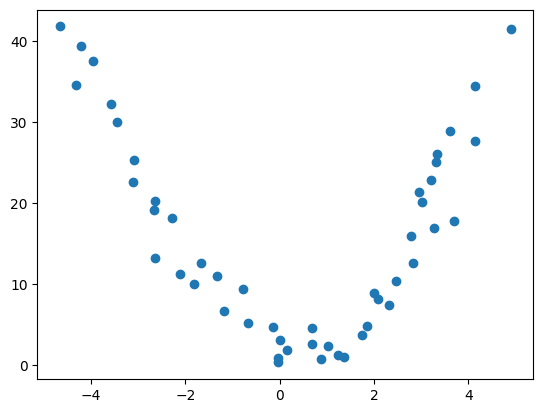

In [207]:
plt.scatter(df['Temperature (°C)'], df['Ice Cream Sales (units)'])

CONCLUSION:
- The plot shows non-linear data.
- It specifically shows, polynomial type of data.

Let us see how the model performs when Linear Regression is used.

defining feature and target column

In [208]:
x = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

In [209]:
model = LinearRegression()

In [210]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, train_size = 0.8, random_state=42)

In [211]:
r2 = r2_score(xtrain, ytrain)
r2

-60.49383740828049

The R² Score is `-60.49383740828049`. The model will not perform well.

In [212]:
model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [213]:
ytrain_pred = model.predict(xtrain)
ytrain_pred

array([19.56065517, 21.24233581, 14.48074687, 20.20342161, 21.66784265,
       20.70330974, 13.45710289, 13.38982355, 12.40281419, 18.66002185,
       20.18029032, 18.48430086, 16.34946599, 14.75993004, 15.14415197,
       22.48490227, 13.31427684, 14.84683012, 21.10148677, 15.58006978,
       19.76290657, 13.94615622, 22.08852349, 17.17807702, 21.9709127 ,
       13.89235407, 14.30491232, 16.96809126, 13.67551832, 20.17938594,
       17.12934365, 17.91172924, 11.52204795, 17.18066969, 20.67219504,
       13.33704794, 19.04294602, 15.71662948, 13.74539387])

In [214]:
mae = mean_absolute_error(ytrain, ytrain_pred)
rmse = root_mean_squared_error(ytrain, ytrain_pred)
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 10.136398159361041
RMSE: 11.972117646423854


RMSE > MAE. The model is not able to capture the outlier pattern properly.

MODEL EVALUATION

In [215]:
ytest_pred = model.predict(xtest)
ytest_pred

array([19.2247831 , 12.89218952, 12.39975758, 12.99914196, 18.0259032 ,
       15.96490086, 16.13605851, 16.34394177, 15.0173946 , 17.3107825 ])

In [216]:
mae = mean_absolute_error(ytest, ytest_pred)
rmse = root_mean_squared_error(ytest, ytest_pred)
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 11.752026695440602
RMSE: 12.219913714640208


### PERFORMING POLYNOMIAL REGRESSION ON THE DATA

In [217]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [218]:
# from sklearn.preprocessing import fit

In [219]:
# creating feature column x and creating target column y
x = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

# splitting the data into train (80%) and test (20%)
xtrain, xtest, ytrain, ytest = train_test_split(x,y, train_size=0.8, random_state=42)

# creating object poly to access class
poly = PolynomialFeatures(degree = 2)

In [220]:
# using fit_transform. 
# fit to create features according to degree. if degree = 2, 1 extra feature is created from xtrain => xtrain²
# transform to create the values of the new features
updated_xtrain = poly.fit_transform(xtrain)

# creating object model to access class LinearRegression
model = LinearRegression()

# using updated_xtrain(3 features) and not xtrain(1 feature)
model.fit(updated_xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [221]:
# poly stores the 3 features created by using poly.fit_transform()
# creating updated_xtest (3 fetaures)
updated_xtest = poly.transform(xtest)
model.predict(updated_xtest)

array([10.24499852, 25.82807714, 31.8241041 , 24.61704203,  4.43380256,
        4.00785672,  3.58277491,  3.17865087,  7.86990452,  2.91591368])

# DAY 3: 17 jun 26

In [222]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

### DATA IS `LINEAR` OR `NON LINEAR`?

In [223]:
df = pd.read_csv("Ice_cream selling data.csv")

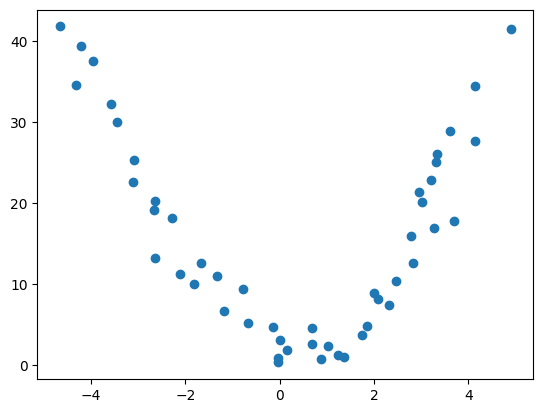

In [224]:
# scatter plot
plt.scatter(df['Temperature (°C)'], df['Ice Cream Sales (units)'])

In [225]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


THe data is non-linear, here we confirmed by using corr()

Relation between `Temperature (°C)` and `Ice Cream Sales (units)` is `-0.175184` units

correlation value is close to zero. so the data is `non-linear`.

In [226]:
x = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

train test split

In [227]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, train_size=0.8, random_state=42)

In [228]:
model = LinearRegression()
model.fit(xtrain, ytrain) # learns the pattern(mx+c) from xtrain, ytrain

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Model Evaluation

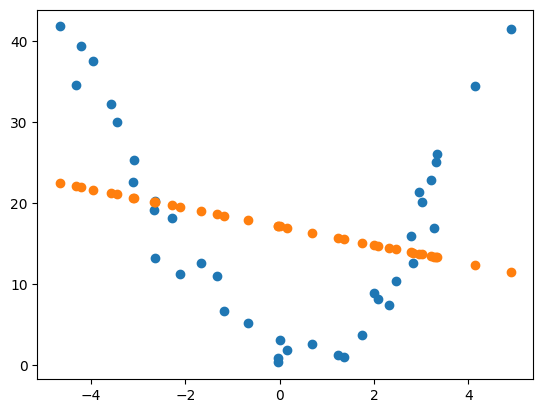

In [229]:
ypred_train = model.predict(xtrain)
plt.scatter(xtrain, ytrain)
plt.scatter(xtrain, ypred_train)

model is not capturing the non-linear pattern

In [230]:
r2 = r2_score(ytrain, ypred_train)
print(f'Train score: {r2}')

Train score: 0.06579063815950037


### Polynomial Features

In [231]:
# from sklearn.preprocessing import PolynomialFeatures

In [232]:
poly = PolynomialFeatures(degree = 1)   # previously used degree = 1

In [233]:
updated_xtrain = poly.fit_transform(xtrain)
updated_xtest = poly.transform(xtest)

In [234]:
xtrain

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661
6,-3.108440
40,3.211366
41,3.270044
46,4.130868
15,-1.326379


In [235]:
updated_xtrain

array([[ 1.        , -2.11186969],
       [ 1.        , -3.57855372],
       [ 1.        ,  2.31859124],
       [ 1.        , -2.67246083],
       [ 1.        , -3.94966109],
       [ 1.        , -3.10844012],
       [ 1.        ,  3.21136614],
       [ 1.        ,  3.27004407],
       [ 1.        ,  4.13086796],
       [ 1.        , -1.32637898],
       [ 1.        , -2.65228679],
       [ 1.        , -1.17312327],
       [ 1.        ,  0.68878091],
       [ 1.        ,  2.0751006 ],
       [ 1.        ,  1.74000001],
       [ 1.        , -4.66226268],
       [ 1.        ,  3.33593241],
       [ 1.        ,  1.99931037],
       [ 1.        , -3.4557117 ],
       [ 1.        ,  1.35981267],
       [ 1.        , -2.288264  ],
       [ 1.        ,  2.78483646],
       [ 1.        , -4.31655945],
       [ 1.        , -0.03389529],
       [ 1.        , -4.21398476],
       [ 1.        ,  2.83176021],
       [ 1.        ,  2.471946  ],
       [ 1.        ,  0.14924457],
       [ 1.        ,

In [236]:
model = LinearRegression()
model.fit(updated_xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [237]:
# ypred_train = model.predict(xtrain) ValueError: X has 1 features, but LinearRegression is expecting 2 features as input.

In [238]:
ypred_train = model.predict(updated_xtrain)

In [239]:
ypred_train

array([19.56065517, 21.24233581, 14.48074687, 20.20342161, 21.66784265,
       20.70330974, 13.45710289, 13.38982355, 12.40281419, 18.66002185,
       20.18029032, 18.48430086, 16.34946599, 14.75993004, 15.14415197,
       22.48490227, 13.31427684, 14.84683012, 21.10148677, 15.58006978,
       19.76290657, 13.94615622, 22.08852349, 17.17807702, 21.9709127 ,
       13.89235407, 14.30491232, 16.96809126, 13.67551832, 20.17938594,
       17.12934365, 17.91172924, 11.52204795, 17.18066969, 20.67219504,
       13.33704794, 19.04294602, 15.71662948, 13.74539387])

In [240]:
# plt.scatter(updated_xtrain, ytrain)         ValueError: x and y must be the same size
# plt.scatter(updated_xtrain, ypred_train)

In [241]:
updated_xtrain[:,1]

array([-2.11186969, -3.57855372,  2.31859124, -2.67246083, -3.94966109,
       -3.10844012,  3.21136614,  3.27004407,  4.13086796, -1.32637898,
       -2.65228679, -1.17312327,  0.68878091,  2.0751006 ,  1.74000001,
       -4.66226268,  3.33593241,  1.99931037, -3.4557117 ,  1.35981267,
       -2.288264  ,  2.78483646, -4.31655945, -0.03389529, -4.21398476,
        2.83176021,  2.471946  ,  0.14924457,  3.02087431, -2.65149803,
        0.0086077 , -0.6737528 ,  4.89903151, -0.0361565 , -3.08130332,
        3.31607252, -1.66034773,  1.24071162,  2.95993209])

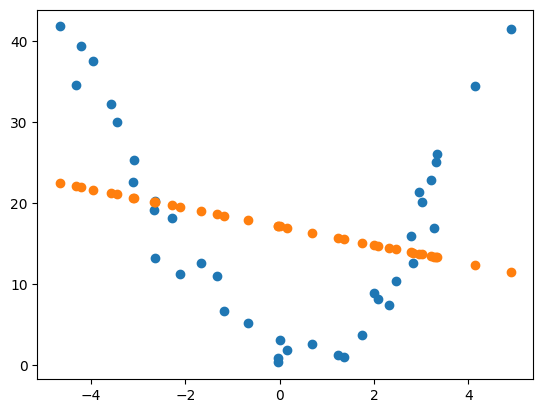

In [242]:
plt.scatter(updated_xtrain[:,1], ytrain)  
plt.scatter(updated_xtrain[:,1], ypred_train)

degree is 1, so no change

use degree = 2

In [243]:
poly = PolynomialFeatures(degree = 2)   # previously used degree = 1, now use 2

In [244]:
updated_xtrain = poly.fit_transform(xtrain)
updated_xtest = poly.transform(xtest)

In [245]:
model = LinearRegression()
model.fit(updated_xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [246]:
ypred_train = model.predict(updated_xtrain)

In [247]:
updated_xtrain[:,1]

array([-2.11186969, -3.57855372,  2.31859124, -2.67246083, -3.94966109,
       -3.10844012,  3.21136614,  3.27004407,  4.13086796, -1.32637898,
       -2.65228679, -1.17312327,  0.68878091,  2.0751006 ,  1.74000001,
       -4.66226268,  3.33593241,  1.99931037, -3.4557117 ,  1.35981267,
       -2.288264  ,  2.78483646, -4.31655945, -0.03389529, -4.21398476,
        2.83176021,  2.471946  ,  0.14924457,  3.02087431, -2.65149803,
        0.0086077 , -0.6737528 ,  4.89903151, -0.0361565 , -3.08130332,
        3.31607252, -1.66034773,  1.24071162,  2.95993209])

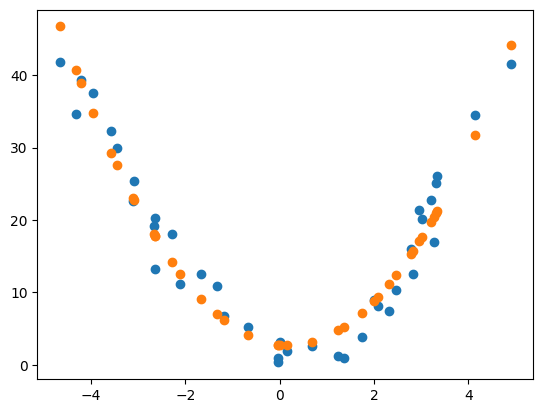

In [248]:
plt.scatter(updated_xtrain[:,1], ytrain)  
plt.scatter(updated_xtrain[:,1], ypred_train)

now model can capture the pattern

In [249]:
# updated_xtrain #1, x, x²

check train and test score after changing the degree to get the best degree

In [250]:
# train score
r2 = r2_score(ytrain, ypred_train)
print(f'Train score: {r2}')
# test score
ypred_test = model.predict(updated_xtest)
r2 = r2_score(ytest, ypred_test)
print(f'Test score: {r2}')

Train score: 0.9413665676490518
Test score: 0.843055137193884


In [251]:
# # train score deg = 2
# r2 = r2_score(ytrain, ypred_train)
# print(f'Train score: {r2}')
# # test score deg = 2
# ypred_test = model.predict(updated_xtest)
# r2 = r2_score(ytest, ypred_test)
# print(f'Test score: {r2}')

In [252]:
# # train score deg = 3
# r2 = r2_score(ytrain, ypred_train)
# print(f'Train score: {r2}')
# # test score deg = 3
# ypred_test = model.predict(updated_xtest)
# r2 = r2_score(ytest, ypred_test)
# print(f'Test score: {r2}')

In [253]:
# # train score deg = 4
# r2 = r2_score(ytrain, ypred_train)
# print(f'Train score: {r2}')
# # test score deg = 4
# ypred_test = model.predict(updated_xtest)
# r2 = r2_score(ytest, ypred_test)
# print(f'Test score: {r2}')

In [254]:
# # train score deg = 5
# r2 = r2_score(ytrain, ypred_train)
# print(f'Train score: {r2}')
# # test score deg = 5
# ypred_test = model.predict(updated_xtest)
# r2 = r2_score(ytest, ypred_test)
# print(f'Test score: {r2}')

degree = 2
- Train score: `0.9413665676490518`
- Test score: `0.843055137193884`

degree = 3
- train score  `0.9469116778215552`
- test score `0.8405107685716915`

degree = 4
- train score ` 0.9590068634754769`
- test score `0.8054468908427623`

degree = 5
- train score `0.9625276778765787`
- test score `0.7781622233034887`

degree = 6
- Train score: `0.9668204963106728`
- Test score: `0.7313950333963021`

In [255]:
# check mae and rmse
mae_train = mean_absolute_error(ytrain, ypred_train)
print(f'MAE Train: {mae_train}')
rmse_train = root_mean_squared_error(ytrain, ypred_train)
print(f'RMSE Train: {rmse_train}')
print()
mae_test = mean_absolute_error(ytest, ypred_test)
print(f'MAE Test: {mae_test}')
rmse_test = root_mean_squared_error(ytest, ypred_test)
print(f'RMSE Test: {rmse_test}')

MAE Train: 2.5993732834161136
RMSE Train: 2.99931118717202

MAE Test: 3.2299819836597274
RMSE Test: 3.857304297171988


degree = 2
- MAE Train: 2.5993732834161136
- RMSE Train: 2.99931118717202

- MAE Test: 3.4214786739709853
- RMSE Test: 5.046233798276592

degree = 3
- MAE Train: 2.43566416014849
- RMSE Train: 2.8539631962901724

- MAE Test: 3.4214786739709853
- RMSE Test: 5.046233798276592

degree = 4
- MAE Train: 2.0963498651499717
- RMSE Train: 2.507866665138919

- MAE Test: 3.4214786739709853
- RMSE Test: 5.046233798276592

Check degree one by one for train and test both. Then decide which degree to use.
- check between 2 to 8 degree
- rare case, if still model dosen't perform well, the non-linear pattern is very complex
  - here, we use tree based model

In [256]:
# take new non-linear data
# perform linear and polynomial regression and write conclusions